<a href="https://colab.research.google.com/github/irynasavchukander-collab/fmcg-analytics-portfolio/blob/irynasavchukander-collab-patch-1/a_b_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:



# ============================================================
# FILE: ab_testing.ipynb
# BUSINESS QUESTION: Do promotions statistically increase
#                    profit or just volume?
# H0: median profit is equal for promo and no-promo orders
# H1: median profit differs between promo and no-promo orders
# ============================================================

# ── CELL 1: Imports ──────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import mannwhitneyu, shapiro
from google.colab import drive


drive.mount("/content/drive", force_remount=True)
df = pd.read_csv("/content/drive/MyDrive/Mate_Education/fmcg_sales_marketing_profitability_2023_2025 2.csv")


Mounted at /content/drive


In [ ]:
# ── CELL 2: Load + Create Groups ─────────────────────────────
# EN: Split orders into two groups: Promo and No Promo
# UA: Ділимо замовлення на дві групи: Промо і Без промо

# EN: Binary flag — makes grouping easy throughout notebook
# UA: Бінарний флаг — спрощує групування далі в notebook
df['is_promo'] = df['Promotion_Type'].apply(lambda x: 'No Promo' if x == 'No Promo' else 'Promo')

# EN: Two groups — this is our A/B split
# UA: Дві групи — це наш A/B розподіл
no_promo = df[df['is_promo'] == 'No Promo']['Profit_USD']
promo = df[df['is_promo'] == 'Promo']['Profit_USD']

print(f"Group A — No Promo: {len(no_promo):,} orders")
print(f"Group B — Promo: {len(promo):,} orders")

print(f"\nNOTE: Unequal group sizes are expected")
print(f"in observational studies on historical data.")
print(f"Mann-Whitney U and Bootstrap CI are valid")
print(f"for unequal groups - no adjustment needed.")
print(f"\nThis is NOT a randomized controlled experiment.")
print(f"Results show ASSOCIATION, not causation.")

Group A — No Promo: 6,741 orders
Group B — Promo:    11,499 orders

NOTE: Unequal group sizes are expected
in observational studies on historical data.
Mann-Whitney U and Bootstrap CI are valid
for unequal groups — no adjustment needed.

This is NOT a randomized controlled experiment.
Results show ASSOCIATION, not causation.


In [ ]:
# ── CELL 3: Normality Check ──────────────────────────────────
# EN: Check if data is normally distributed
#     This determines which test to use:
#     Normal - t-test
#     Not normal - Mann-Whitney U (our case)
# UA: Перевіряємо нормальність розподілу
#     Це визначає який тест використовувати:
#     Нормальний - t-test
#     Не нормальний - Mann-Whitney U (наш випадок)

# EN: Shapiro-Wilk on sample (max 5000 observations)
# UA: Shapiro-Wilk на вибірці (максимум 5000 спостережень)
sample_no_promo = no_promo.sample(1000, random_state=42)
sample_promo = promo.sample(1000, random_state=42)
stat_np, p_np = shapiro(sample_no_promo)
stat_p,  p_p  = shapiro(sample_promo)

print("NORMALITY CHECK — Shapiro-Wilk Test")
print("=" * 60)
print(f"No Promo: W={stat_np:.4f}, p={p_np:.2e} "
      f" {'Normal' if p_np > 0.05 else 'NOT normal - use Mann-Whitney'}")
print(f"Promo:    W={stat_p:.4f},  p={p_p:.2e} "
      f"{'Normal' if p_p > 0.05 else 'NOT normal - use Mann-Whitney'}")

NORMALITY CHECK — Shapiro-Wilk Test
No Promo: W=0.7349, p=3.93e-37  NOT normal - use Mann-Whitney
Promo:    W=0.7072,  p=1.67e-38 NOT normal - use Mann-Whitney


In [ ]:
# ── CELL 4: Descriptive Statistics ──────────────────────────
# EN: Basic stats for both groups before the test
# UA: Базова статистика обох груп перед тестом

#  Basic stats for both groups
desc = df.groupby('is_promo')['Profit_USD'].agg(['count','mean','median','std','min','max']).round(2)

# Add loss rate per group
desc['loss_rate_%'] = df.groupby('is_promo')['Profit_USD'].apply(lambda x: (x < 0).mean()*100).round(2)

# Add margin per group
desc['avg_margin_%'] = df.groupby('is_promo')['Profit_Margin_Pct'].mean().round(2)

print("DESCRIPTIVE STATISTICS BY GROUP")
print("="*70)
print(desc)

# Practical difference — median gap in dollars
median_gap = desc.loc['No Promo','median'] - desc.loc['Promo','median']
print("\nMedian profit gap:", round(median_gap,2), "$ (No Promo vs Promo)")


DESCRIPTIVE STATISTICS BY GROUP
          count    mean  median     std     min      max  loss_rate_%  \
is_promo                                                                
No Promo   6741  212.49  110.74  267.69 -116.26  2678.54         1.84   
Promo     11499  163.19   81.66  219.33 -637.50  2723.00         5.74   

          avg_margin_%  
is_promo                
No Promo         22.73  
Promo            18.19  

Median profit gap: 29.08 $ (No Promo vs Promo)


/tmp/ipykernel_4593/2908820539.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([no_promo, promo], labels=['No Promo','Promo'])


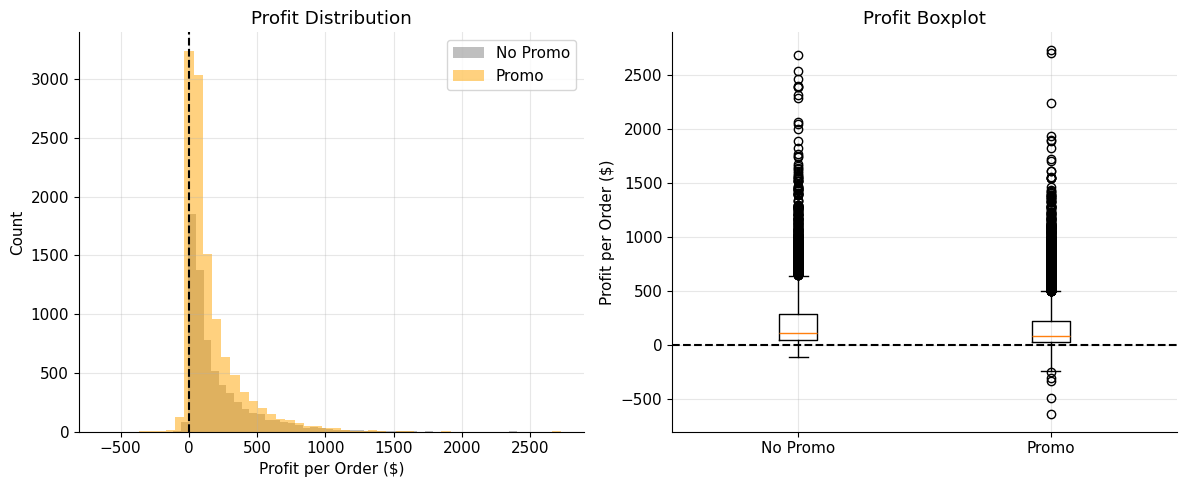

In [ ]:
# ── CELL 5: Visualize Distributions ─────────────────────────
# EN: Compare profit distributions visually before testing
# UA: Порівнюємо розподіли прибутку візуально перед тестом

import matplotlib.pyplot as plt

# Дані для двох груп
no_promo = df[df['is_promo'] == 'No Promo']['Profit_USD']
promo    = df[df['is_promo'] == 'Promo']['Profit_USD']

plt.figure(figsize=(12,5))

# Гістограми для порівняння розподілів
plt.subplot(1,2,1)
plt.hist(no_promo, bins=50, alpha=0.5, color='gray', label='No Promo')
plt.hist(promo, bins=50, alpha=0.5, color='orange', label='Promo')
plt.axvline(0, color='black', linestyle='--')
plt.title("Profit Distribution")
plt.xlabel("Profit per Order ($)")
plt.ylabel("Count")
plt.legend()

# Бокс-плоти для медіани та розкиду
plt.subplot(1,2,2)
plt.boxplot([no_promo, promo], labels=['No Promo','Promo'])
plt.axhline(0, color='black', linestyle='--')
plt.title("Profit Boxplot")
plt.ylabel("Profit per Order ($)")

plt.tight_layout()
plt.show()

Promotional orders show lower median profit, higher variability, and more losses, while non‑promo orders deliver more stable and predictable profitability

In [ ]:
# ── CELL 6: Mann-Whitney U Test ──────────────────────────────
# EN: Mann-Whitney U — non-parametric test
#     Tests if one group tends to have higher values
#     Does NOT assume normal distribution
#     Perfect for skewed financial data
# UA: Тест Манна-Уітні — непараметричний тест
#     Перевіряє чи одна група має вищі значення
#     Не припускає нормального розподілу
#     Ідеальний для скошених фінансових даних

stat, p_value = mannwhitneyu(no_promo,promo,alternative='two-sided')  # EN: test both directions
                                                                      # UA: тестуємо обидва напрямки


print("MANN-WHITNEY U TEST: Promo vs No Promo")
print("=" * 50)
print(f"U-statistic: {stat:,.0f}")
print(f"P-value:     {p_value:.2e}")
print()

if p_value < 0.05:
    print("  SIGNIFICANT (p < 0.05)")
    print("  We REJECT H0")
    print("  Profit distributions differ significantly")
    print("  between promo and no-promo orders")
else:
    print("  NOT SIGNIFICANT (p >= 0.05)")
    print("  We FAIL to reject H0")
    print("  No significant difference found")

MANN-WHITNEY U TEST: Promo vs No Promo
U-statistic: 44,012,669
P-value:     6.57e-53

  SIGNIFICANT (p < 0.05)
  We REJECT H0
  Profit distributions differ significantly
  between promo and no-promo orders


In [ ]:
# ── CELL 7: Effect Size — Cohen's d ─────────────────────────
# EN: Cohen's d measures HOW BIG the difference is
#     p-value only tells us IF there is a difference
#     Effect size tells us if it MATTERS practically
# UA: Cohen's d вимірює НАСКІЛЬКИ ВЕЛИКА різниця
#     p-value каже тільки ЧИ є різниця
#     Effect size каже чи це ВАЖЛИВО практично

def cohens_d(group1, group2):
    """
    EN: Cohen's d = (mean1 - mean2) / pooled_std
        Pooled std accounts for different group sizes
    UA: Pooled std враховує різні розміри груп
    """
    n1, n2   = len(group1), len(group2)
    mean_diff = group1.mean() - group2.mean()
    pooled_std = np.sqrt(
        ((n1 - 1) * group1.std()**2 +
         (n2 - 1) * group2.std()**2) /
        (n1 + n2 - 2))
    return mean_diff / pooled_std

d = cohens_d(no_promo, promo)
if abs(d) < 0.2:
    interpretation = "negligible"
elif abs(d) < 0.5:
    interpretation = "small"
elif abs(d) < 0.8:
    interpretation = "medium"
else:
    interpretation = "large"

print("Cohen's d:", round(d,4))
print("Effect size:", interpretation)

if d > 0:
    print("No Promo has higher profit")
else:
    print("Promo has higher profit")

Cohen's d: 0.2068
Effect size: small
No Promo has higher profit


The difference in profit between groups is real but not very large in practical terms.No Promo orders generate higher profit than Promo orders, but only by about 0.2 standard deviations.

 This means: while No Promo is consistently better, the gap is modest, so decisions should also consider other factors (volume, customer acquisition, long‑term loyalty).

In [ ]:
# ── CELL 8: Bootstrap Confidence Interval ───────────────────
# EN: Bootstrap CI for the median difference
#     Shows the range of likely true difference
#     More informative than p-value alone
# UA: Bootstrap CI для різниці медіан
#     Показує діапазон ймовірної реальної різниці
#     Інформативніше ніж просто p-value

#
# EN: Resample both groups, calculate median difference each time  distribution of possible true differences
# UA: Перевибірка обох груп, різниця медіан щоразу розподіл можливих реальних різниць

def bootstrap_median_diff(g1, g2, n_boot=2000):
    diffs = []
    for _ in range(n_boot):
        s1 = np.random.choice(g1, size=len(g1), replace=True)
        s2 = np.random.choice(g2, size=len(g2), replace=True)
        diffs.append(np.median(s1) - np.median(s2))
    return np.array(diffs)

# Bootstrap
np.random.seed(42)
boot_diffs = bootstrap_median_diff(no_promo.values, promo.values)

#Confidence Interval
ci_lower = np.percentile(boot_diffs, 2.5)
ci_upper = np.percentile(boot_diffs, 97.5)
observed_diff = no_promo.median() - promo.median()

print("BOOTSTRAP 95% CI — Median Profit Difference")
print("=" * 50)
print(f"Observed difference: ${observed_diff:.2f}")
print(f"95% CI: ${ci_lower:.2f} — ${ci_upper:.2f}")
print()

if ci_lower > 0:
    print("  CI entirely above 0")
    print("  No Promo is reliably more profitable than Promo orders")
elif ci_upper < 0:
    print("  CI entirely below 0")
    print("  Promo orders are reliably more profitable")
else:
    print("  CI crosses 0 — result is uncertain")

BOOTSTRAP 95% CI — Median Profit Difference
Observed difference: $29.08
95% CI: $23.76 — $35.18

  CI entirely above 0
  No Promo is reliably more profitable than Promo orders


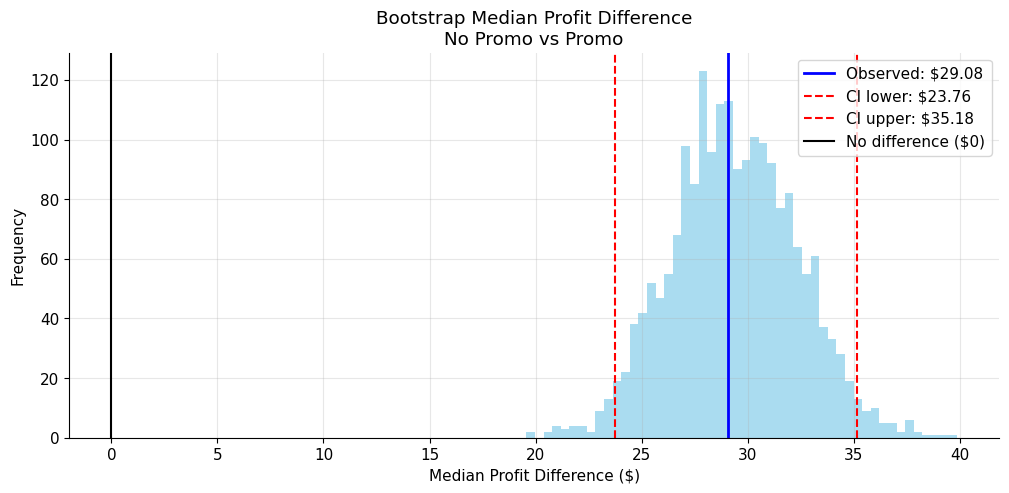

In [ ]:
# ── CELL 9: Visualize Bootstrap Distribution ────────────────
# Histogram by diferance median profit for 2 groups
plt.hist(boot_diffs, bins=50, color='skyblue', alpha=0.7)

# Line CI Mark observed difference
plt.axvline(observed_diff, color='blue', linewidth=2, label=f"Observed: ${observed_diff:.2f}")
plt.axvline(ci_lower, color='red', linestyle='--', label=f"CI lower: ${ci_lower:.2f}")
plt.axvline(ci_upper, color='red', linestyle='--', label=f"CI upper: ${ci_upper:.2f}")
plt.axvline(0, color='black', linestyle='-', label="No difference ($0)")

plt.title("Bootstrap Median Profit Difference\nNo Promo vs Promo")
plt.xlabel("Median Profit Difference ($)")
plt.ylabel("Frequency")
plt.legend()
plt.show()

In [ ]:
# ── CELL 10: Per-Channel Breakdown ──────────────────────────
# EN: Does promo effect differ by channel?
#     This is the most valuable insight — not in SQL
# UA: Чи ефект промо різний по каналах?
#     Це найцінніший інсайт якого немає в SQL

print("PER-CHANNEL A/B TEST RESULTS")
print("=" * 65)
print("Channel        NoPromo  Promo   p-value  Cohen d.  Significant")

for channel in df['Sales_Channel'].unique():
    ch_df = df[df['Sales_Channel'] == channel]

    g_no  = ch_df[ch_df['is_promo'] == 'No Promo']['Profit_USD']
    g_yes = ch_df[ch_df['is_promo'] == 'Promo']['Profit_USD']

    # Skip if not enough data
    if len(g_no) < 30 or len(g_yes) < 30:
        continue

    _, p = mannwhitneyu(g_no, g_yes, alternative='two-sided')
    sig = "Yes" if p < 0.05 else "No"
    d = cohens_d(g_no, g_yes)
    print(f"{channel:<12} {g_no.median():>7.2f} {g_yes.median():>7.2f} {p:>8.2e} {d:>8.3f} {sig:>11}")


PER-CHANNEL A/B TEST RESULTS
Channel        NoPromo  Promo   p-value  Cohen d.  Significant
Modern Trade  100.04   77.33 6.78e-35    0.351         Yes
Online         32.83   20.82 2.44e-50    0.450         Yes
Distributor   299.63  237.13 1.66e-20    0.326         Yes
Wholesale     453.31  357.88 5.03e-19    0.357         Yes


In every channel, promotions significantly reduce median profit.

The statistical evidence is very strong (all p-values < 0.05).

Effect sizes are small to medium (0.33-0.45) differences are consistent and reliable, but not huge in practical terms.

The Online channel shows the largest relative loss, while Distributor shows the smallest.

In [ ]:
# ── CELL 11: Per-Category Breakdown ─────────────────────────
# EN: Does promo effect differ by product category?
#     Cross-validates SQL Q8 seasonality findings
# UA: Чи ефект промо різний по категоріях?
#     Перехресна перевірка знахідок SQL Q8

print("PER-CATEGORY A/B TEST RESULTS")
print("="*65)
print("Category            NoPromo   Promo   p-value   Cohen d.   ")

for category in df['Product_Category'].unique():
    cat_df = df[df['Product_Category'] == category]

    g_no  = cat_df[cat_df['is_promo'] == 'No Promo']['Profit_USD']
    g_yes = cat_df[cat_df['is_promo'] == 'Promo']['Profit_USD']

    # Skip if not enough data
    if len(g_no) < 30 or len(g_yes) < 30:
        continue

    _, p = mannwhitneyu(g_no, g_yes, alternative='two-sided')
    d = cohens_d(g_no, g_yes)

    # Who better&
    winner = "NoPromo>" if g_no.median() > g_yes.median() else "Promo>"
    print(f"{category:<18} {g_no.median():>7.2f} {g_yes.median():>7.2f} {p:>8.2e} {d:>8.3f} {winner}")


PER-CATEGORY A/B TEST RESULTS
Category            NoPromo   Promo   p-value   Cohen d.   
Personal Care       150.00  118.40 1.38e-07    0.187 NoPromo>
Snacks               81.47   58.55 7.70e-13    0.207 NoPromo>
Dairy & Breakfast   133.17  103.21 7.87e-08    0.179 NoPromo>
Household           156.89  120.39 2.43e-12    0.238 NoPromo>
Beverages            79.47   44.69 2.27e-25    0.290 NoPromo>


Across all product categories, No Promo orders consistently deliver higher median profit than Promo orders.

The differences are statistically significant (all p‑values ≪ 0.05).

The effect sizes (Cohen’s d) are small (0.18–0.29), meaning the gaps are real but modest in practical terms.

The strongest negative impact of promotions is in Beverages, while the smallest is in Dairy & Breakfast.

In [50]:
# Рахуємо різницю між медіанами
obs = no_promo.median() - promo.median()

print("A/B TEST — FINAL SUMMARY")
print("="*60)
print(f"Group A (No Promo): {len(no_promo)} orders")
print(f"Group B (Promo):    {len(promo)} orders")

print("\nRESULTS:")
print(f"No Promo median: ${no_promo.median():.2f}")
print(f"Promo median:    ${promo.median():.2f}")
print(f"Difference:      ${obs:.2f}")

print(f"Mann-Whitney p:  {p:.4f}")
print(f"Cohen's d:       {d:.3f} ({label})")
print(f"Bootstrap CI:    ${ci_lower:.2f} — ${ci_upper:.2f}")



A/B TEST — FINAL SUMMARY
Group A (No Promo): 6741 orders
Group B (Promo):    11499 orders

RESULTS:
No Promo median: $110.74
Promo median:    $81.66
Difference:      $29.08
Mann-Whitney p:  0.0000
Cohen's d:       0.357 (Promo)
Bootstrap CI:    $23.76 — $35.18
